In [8]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Add src folder to the path
sys.path.append(os.path.abspath('../src'))
# Add parent directory to the path for relative imports
sys.path.append(os.path.abspath('..'))

from data_utils import load_bitstream, apply_error_correction
from modulator import (
    apply_tukey_window,
    map_bits_to_symbols,
    normalize_audio,
    pulse_shape_symbols,
    to_int16_pcm,
    upconvert_to_passband,
)
from plot_utils import plot_complex_parts, plot_fft, plot_waveform
from sync import assemble_baseband_frame, generate_zadoff_chu_audio
import notebooks.config as config

In [9]:
FS = config.FS             # Sample rate (Hz)
F_CARRIER = config.F_CARRIER      # Center frequency (10 kHz is safely in your 2-18kHz window)

# Start conservative to test the channel, then increase for more points!
SYMBOL_RATE = config.SYMBOL_RATE     # Symbols per second (Baud)

# Calculate how many audio samples represent one symbol
# 48000 Hz / 7000 Baud = 6.86 samples per symbol
SAMPLES_PER_SYMBOL = FS // SYMBOL_RATE

print(f"Carrier Frequency: {F_CARRIER} Hz")
print(f"Symbol Rate: {SYMBOL_RATE} Baud")
print(f"Samples per Symbol: {SAMPLES_PER_SYMBOL}")
print(f"Main Lobe Bandwidth: ~{2 * SYMBOL_RATE} Hz (From {F_CARRIER - SYMBOL_RATE} Hz to {F_CARRIER + SYMBOL_RATE} Hz)")


Carrier Frequency: 10000 Hz
Symbol Rate: 8 Baud
Samples per Symbol: 5512
Main Lobe Bandwidth: ~16 Hz (From 9992 Hz to 10008 Hz)


In [10]:
M = 4  # Change to 4, 16, 64, or 256
bits_per_symbol = int(np.log2(M))
total_bits = 9 * bits_per_symbol

In [12]:
input_path = "../data/message.txt"  # need to make a program which converts the message to bits
read_flag = True

if read_flag:
    if not os.path.exists(input_path):
        raise FileNotFoundError("message.txt not found")

    with open(input_path, "r") as f:
        content = f.read().strip()

    if len(content) == 0:
        raise ValueError("File is empty. Cannot read message bits.")

    message_bits = np.array(list(map(int, content)))
else:
    message_bits = np.random.randint(0, 2, total_bits)

    with open(input_path, "w") as f:
        f.write("".join(map(str, message_bits)))

qam_symbols = map_bits_to_symbols(message_bits, M, METHOD="QAM")

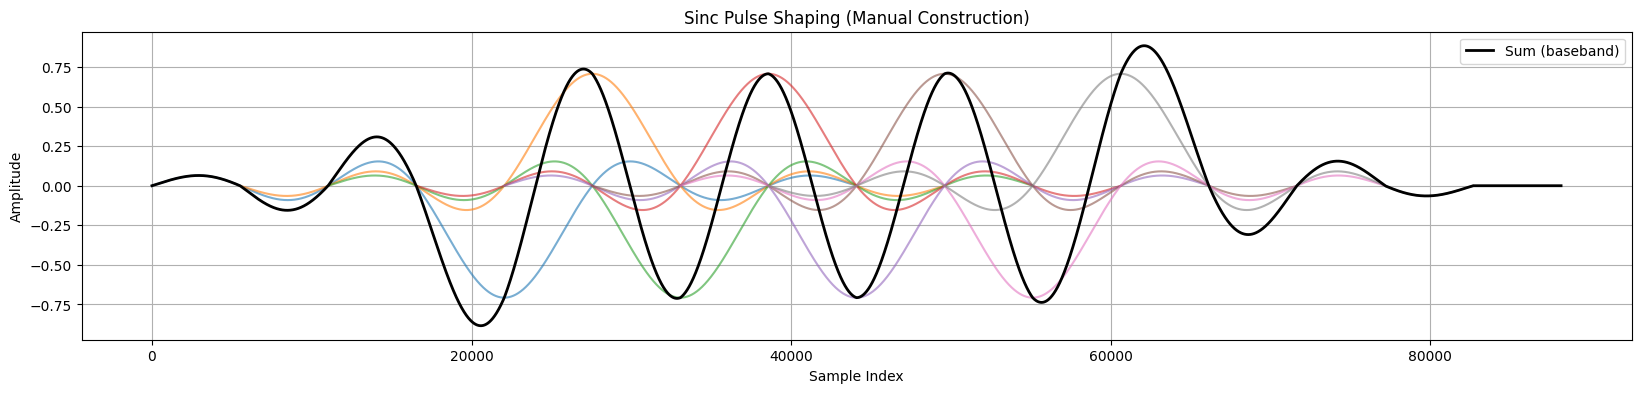

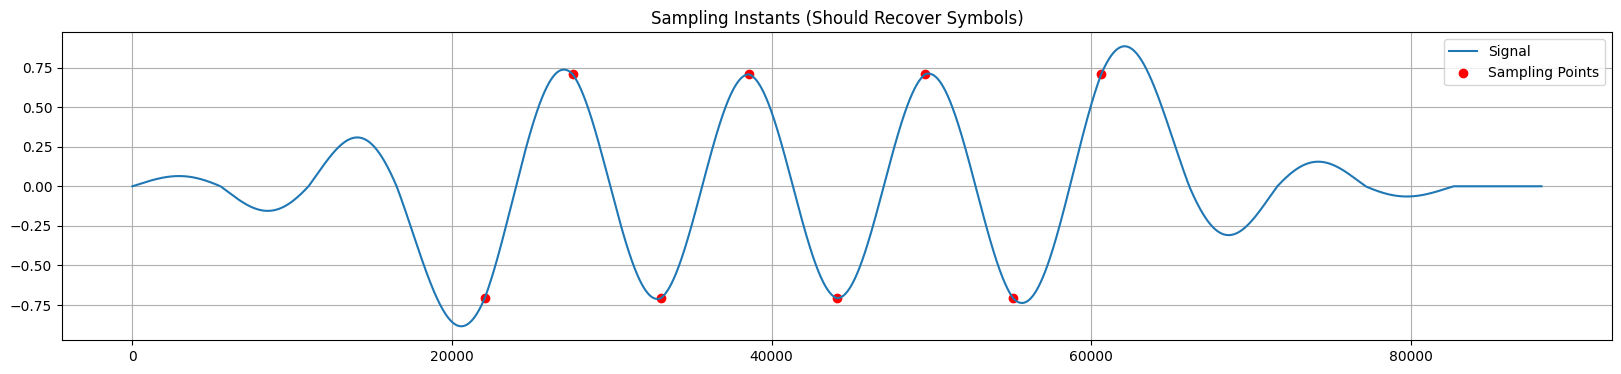


Original symbols (first 10):
[-0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
 -0.70710678+0.70710678j  0.70710678-0.70710678j]

Recovered samples (first 10):
[-0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
 -0.70710678+0.70710678j  0.70710678-0.70710678j]


In [13]:
L = SAMPLES_PER_SYMBOL      
SPAN = 4                    # ±4 symbols

# TIME AXIS FOR SINC

t = np.arange(-SPAN*L, SPAN*L + 1) / L   # normalized time
sinc_base = np.sinc(t)


N = len(qam_symbols)
baseband_signal = np.zeros((N + 2*SPAN) * L, dtype=complex)

plt.figure(figsize=(20,4))

for i in range(N):
    
    # Center of current symbol
    center = (i + SPAN) * L
    
    # Start and end indices
    start = center - len(sinc_base)//2
    end   = start + len(sinc_base)
    
    # Add pulse 
    baseband_signal[start:end] += qam_symbols[i] * sinc_base
    
    # Plot individual pulse (for visualization)
    plt.plot(np.arange(start, end), np.real(qam_symbols[i] * sinc_base), alpha=0.6)

# ================================
# PLOT FINAL SIGNAL
# ================================
plt.plot(np.real(baseband_signal), 'k', linewidth=2, label="Sum (baseband)")
plt.title("Sinc Pulse Shaping (Manual Construction)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# SAMPLING POINTS (VERIFY ZERO ISI)
# ================================
sample_points = np.arange(SPAN*L, (SPAN+N)*L, L)

plt.figure(figsize=(20,4))
plt.plot(np.real(baseband_signal), label="Signal")
plt.scatter(sample_points,
            np.real(baseband_signal[sample_points]),
            color='red', label="Sampling Points")
plt.title("Sampling Instants (Should Recover Symbols)")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# CHECK RECOVERY
# ================================
recovered = baseband_signal[sample_points]

print("\nOriginal symbols (first 10):")
print(qam_symbols[:10])

print("\nRecovered samples (first 10):")
print(recovered[:10])

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

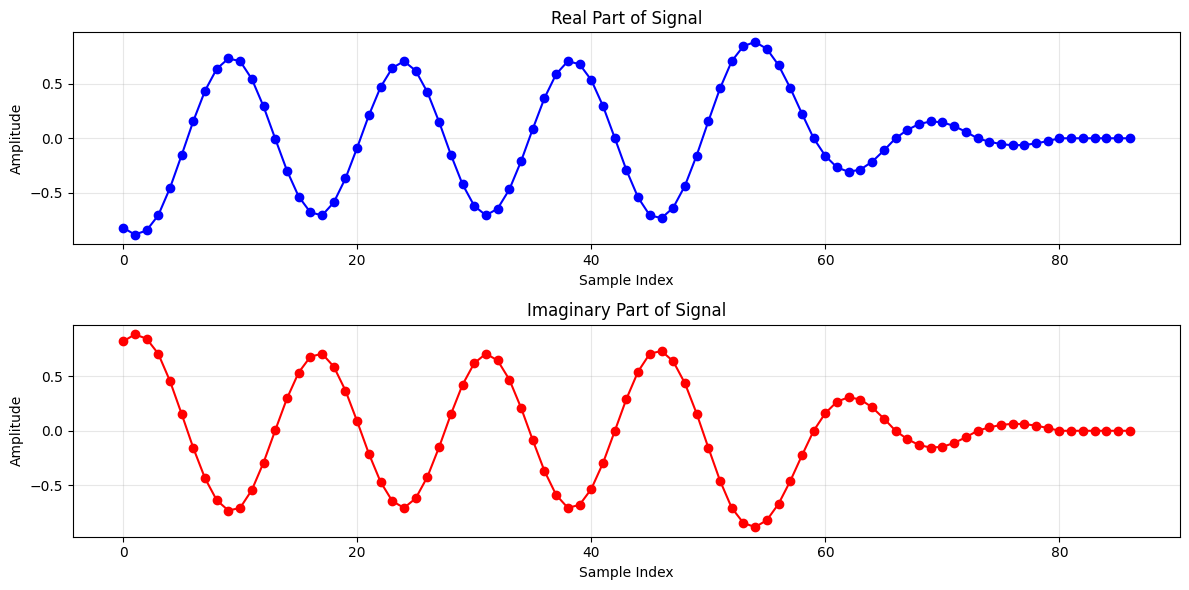

In [165]:

#truncating the starting part so that the first symbol appears in the first samples_per_symbol samples
baseband_signal = baseband_signal[SPAN*L-3:] 
plot_complex_parts(baseband_signal)
print